In [2]:
import pandas as pd
import numpy as np

# -----------------------------------
# 1. Load the two CSV files
# -----------------------------------

ab_df = pd.read_csv(r"C:\Users\yadavalli charishma\Downloads\splits\splits_final\ab_split.csv")
abag_df = pd.read_csv(r"C:\Users\yadavalli charishma\Downloads\splits\splits_final\abag_split.csv")


# -----------------------------------
# 2. Check that they contain
#    the same samples
# -----------------------------------

print(ab_df.shape)
print(abag_df.shape)

print((ab_df["PDB_ID"] == abag_df["PDB_ID"]).all())


# -----------------------------------
# 3. Use the antibody-antigen CSV
#    for the actual samples
# -----------------------------------

df = abag_df.copy()


# -----------------------------------
# 4. Standard 20 amino acids
# -----------------------------------

amino_acids = "ACDEFGHIKLMNPQRSTVWY"

aa_to_index = {
    aa: i for i, aa in enumerate(amino_acids)
}


# -----------------------------------
# 5. Clean sequences
# -----------------------------------

def clean_sequence(seq):

    if pd.isna(seq):
        return ""

    seq = str(seq).upper()

    # Keep only the 20 standard amino acids
    seq = "".join(
        aa for aa in seq
        if aa in amino_acids
    )

    return seq


# -----------------------------------
# 6. Create 20x20 matrix
# -----------------------------------

def create_matrix(antibody_seq, antigen_seq):

    antibody_seq = clean_sequence(antibody_seq)
    antigen_seq = clean_sequence(antigen_seq)

    matrix = np.zeros((20, 20), dtype=np.float32)

    if len(antibody_seq) == 0 or len(antigen_seq) == 0:
        return matrix

    # Count antibody amino acids
    antibody_counts = np.zeros(20)

    for aa in antibody_seq:
        antibody_counts[aa_to_index[aa]] += 1


    # Count antigen amino acids
    antigen_counts = np.zeros(20)

    for aa in antigen_seq:
        antigen_counts[aa_to_index[aa]] += 1


    # Create pair-frequency matrix
    matrix = np.outer(
        antibody_counts,
        antigen_counts
    )


    # Normalize
    total = matrix.sum()

    if total > 0:
        matrix = matrix / total

    return matrix.astype(np.float32)

(15641, 47)
(15641, 48)
True


In [3]:
# -----------------------------------
# 7. Remove samples without antigen
# -----------------------------------

df = df[
    df["concatCDRseq"].notna() &
    df["agresolvedseqs"].notna()
].copy()


# -----------------------------------
# 8. Generate matrices
# -----------------------------------

matrices = []

for _, row in df.iterrows():

    matrix = create_matrix(
        row["concatCDRseq"],
        row["agresolvedseqs"]
    )

    matrices.append(matrix)


# Convert to NumPy array
X = np.array(matrices)

print("Matrix shape:", X.shape)

Matrix shape: (8455, 20, 20)


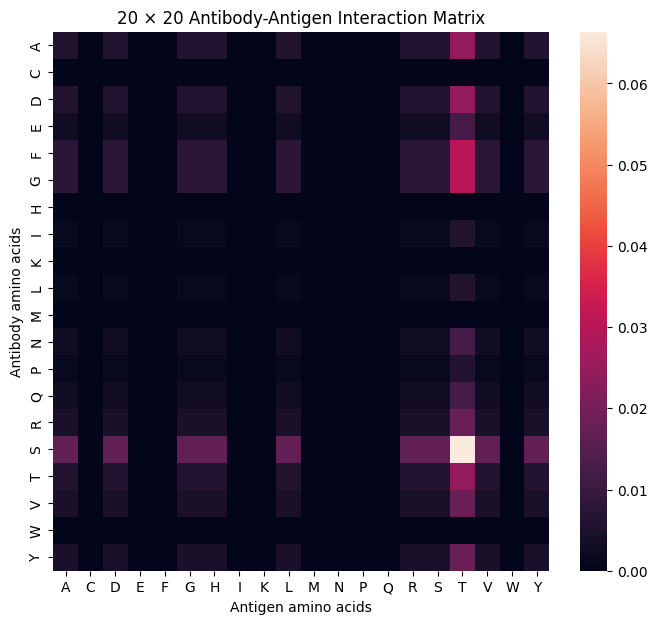

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

plt.figure(figsize=(8, 7))

sns.heatmap(
    X[0, :, :],
    xticklabels=amino_acids,
    yticklabels=amino_acids
)

plt.xlabel("Antigen amino acids")
plt.ylabel("Antibody amino acids")
plt.title("20 × 20 Antibody-Antigen Interaction Matrix")

plt.show()

In [6]:
print(df.columns.tolist())

['INSTANCE', 'PDB_ID', 'SABDAB_ID', 'HEAVY_ID', 'LIGHT_ID', 'PDBdepo', 'SABDABdepo', 'SABDABupdate', 'method', 'resolution', 'type', 'construct', 'species', 'holo', 'Hchain', 'Lchain', 'Hseq', 'Lseq', 'Hseq_expected', 'Lseq_expected', 'VH_numerable_seq', 'VL_numerable_seq', 'VH_numbering_list', 'VL_numbering_list', 'CDRH1', 'CDRH2', 'CDRH3', 'CDRL1', 'CDRL2', 'CDRL3', 'concatCDRseq', 'CDRH123', 'CDRL123', 'agchains', 'agtypes', 'ag_index_list', 'agresolvedseqs', 'agexpectedseqs', 'agresolvedseq_trim_intervals', 'VH_imgt_keep_interval', 'VL_imgt_keep_interval', 'cdrh3_cluster', 'cdrh123_cluster', 'cdrl123_cluster', 'ab_cluster', 'agclusters', 'ab_ag_cluster', 'ab_ag_split']


In [7]:
print(df["ab_ag_split"].value_counts())

ab_ag_split
train    6729
test     1726
Name: count, dtype: int64


In [8]:
print(df.head())

           INSTANCE        PDB_ID   SABDAB_ID HEAVY_ID LIGHT_ID     PDBdepo  \
0  pdb_00001ejo_H_L  pdb_00001ejo  H0005L0004    H0005    L0004  2000-03-03   
2  pdb_00001clz_H_L  pdb_00001clz  H0006L0005    H0006    L0005  1995-03-15   
3  pdb_00001cly_H_L  pdb_00001cly  H0006L0005    H0006    L0005  1995-03-15   
7  pdb_00001j1p_H_L  pdb_00001j1p  H0009L0008    H0009    L0008  2002-12-13   
9  pdb_00001nbz_B_A  pdb_00001nbz  H000AL0009    H000A    L0009  2002-12-04   

   SABDABdepo  SABDABupdate method  resolution  ...  \
0    20260325      20260430   XRAY        2.30  ...   
2    20260325      20260430   XRAY        2.80  ...   
3    20260325      20260430   XRAY        2.50  ...   
7    20260325      20260430   XRAY        1.80  ...   
9    20260326      20260430   XRAY        1.85  ...   

   agresolvedseq_trim_intervals   VH_imgt_keep_interval  \
0  [[[3136, " "], [3148, " "]]]  [[2, " "], [128, " "]]   
2                  [null, null]  [[1, " "], [128, " "]]   
3                

In [9]:
print(df["ab_cluster"].value_counts())
print(df["agclusters"].value_counts())
print(df["ab_ag_cluster"].value_counts())

ab_cluster
1311    605
211     362
297      81
128      64
166      64
       ... 
4136      1
4134      1
23        1
21        1
15        1
Name: count, Length: 2656, dtype: int64
agclusters
P18          936
/            720
P17          557
//           266
///          141
            ... 
P156//         1
P65/P65//      1
P65/P65/       1
//P30/         1
P135           1
Name: count, Length: 1628, dtype: int64
ab_ag_cluster
2       1694
171      972
65       333
337      219
48       178
        ... 
1360       1
1354       1
1349       1
19         1
2541       1
Name: count, Length: 1050, dtype: int64


In [10]:
print(df[[
    "PDB_ID",
    "ab_cluster",
    "agclusters",
    "ab_ag_cluster",
    "ab_ag_split"
]].head(20))

          PDB_ID  ab_cluster agclusters  ab_ag_cluster ab_ag_split
0   pdb_00001ejo           0       E249              0       train
2   pdb_00001clz           1          /              1       train
3   pdb_00001cly           1          /              1       train
7   pdb_00001j1p           4       P364              4       train
9   pdb_00001nbz           5       P364              4       train
10  pdb_00001dqj           5       P364              4       train
11  pdb_00001nby           5       P364              4       train
18  pdb_00001kc5           7        E20              6       train
19  pdb_00001kir           8       P364              4       train
22  pdb_00001him          10        E63              8       train
23  pdb_00001hin          10        E63              8       train
25  pdb_00001ifh          10        E63              8       train
26  pdb_00001him          10        E63              8       train
30  pdb_00001e6j          12       P465             10       t

In [13]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\yadavalli charishma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

model = Sequential([

    # Input
    Input(shape=(20, 20, 1)),

    # Convolution 1
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution 2
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convolution 3
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    # Flatten
    Flatten(),

    # MLP
    Dense(
        512,
        activation="relu"
    ),

    Dense(
        64,
        activation="relu"
    ),

    # Output
    Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 20, 20, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 10, 10, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 10, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 5, 5, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         410,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 461,825 (1.76 MB)

 Trainable params: 461,825 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!
